# Code sophistication vs. competition results — the whole corpus

Two figures from the San Diego study, **recomputed across every team we have repos for** (not just
the 24 San Diego teams), with **San Diego teams colored differently** so you can see where they sit
in the national structure:

1. **Which rubric dimensions track on-field results?** — per-dimension Spearman correlation with EPA.
2. **Code sophistication vs. results** — each team's rubric total vs. its Statbotics EPA.

> **What changed from the original.** The original scored **24 San Diego** teams **by hand** and
> plotted California **state percentile**. This recomputes with the **automated rubric pass** (the
> DuckDB/tree-sitter signals — candidate D1–D8, which match the hand scores at Spearman ≈ 0.69) over
> **all corpus teams**, and uses **normalized EPA** as the cross-comparable results metric (the corpus
> spans many states, so a single state's percentile isn't apples-to-apples). The dataset is written to
> `data/rubric-epa-dataset.csv`.

In [1]:
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})
NAT, SD = "#4878a8", "#f59e0b"   # national = blue, San Diego = orange
GREEN, FIT = "#6aa84f", "#c0392b"

def _root():
    for b in [Path.cwd(), *Path.cwd().parents]:
        if (b/"data"/"code-index.duckdb").exists(): return b
    raise FileNotFoundError("run `python3 main.py index-db` first")
ROOT = _root()
con = duckdb.connect(str(ROOT/"data"/"code-index.duckdb"), read_only=True)
def q(sql): return con.execute(sql).df()
def spearman(a, b): return a.rank().corr(b.rank())   # Pearson on ranks (no scipy)

# EPA + San Diego provenance from the corpus dataset.
master = json.loads((ROOT/"data"/"master-dataset.json").read_text())
epa_rows, meta_rows = [], []
for t in master["teams"]:
    src = t["sources"]
    meta_rows.append({"team": t["team"], "name": t["name"],
                      "source": "both" if len(src) == 2 else src[0],
                      "is_sandiego": "sandiego" in src})
    for e in t.get("epa", []):
        if e.get("status") == "ok":
            epa_rows.append({"team": t["team"], "year": e["year"], "norm_epa": e["norm_EPA"],
                             "state_pctile": e["state_pctile"], "winrate": e["winrate"],
                             "epa_points": e["epa_points"]})
epa_df = pd.DataFrame(epa_rows)
meta_df = pd.DataFrame(meta_rows)
print(f"{len(meta_df)} teams ({meta_df.is_sandiego.sum()} San Diego) | {len(epa_df)} team-year EPA rows")

63 teams (29 San Diego) | 298 team-year EPA rows


In [2]:
# ── Automated rubric scorer (verbatim from scripts/build_notebook.py) ──────────────────────
f_sym = q('''SELECT team,year,
  count(*) FILTER (WHERE kind='interface' AND name LIKE '%IO') io_iface,
  count(*) FILTER (WHERE kind='class' AND name LIKE '%IOSim') io_sim,
  count(*) FILTER (WHERE kind='class' AND (name LIKE '%IOReal' OR name LIKE '%IOTalonFX')) io_real,
  count(*) FILTER (WHERE name LIKE '%IONull' OR name LIKE '%IOReplay' OR name LIKE '%IdealSim') io_adv,
  count(*) FILTER (WHERE name LIKE '%ServoMotorSubsystem') servomotor,
  count(*) FILTER (WHERE name LIKE '%Superstructure' OR name LIKE '%RobotManager') coordinator,
  count(*) FILTER (WHERE kind='enum' AND (name LIKE '%WantedState' OR name LIKE '%SystemState')) fsm,
  count(*) FILTER (WHERE name LIKE '%AStarSolver' OR name LIKE '%BehaviorTree%') graph,
  count(*) FILTER (WHERE name='simulationPeriodic') sim_periodic,
  count(*) FILTER (WHERE name LIKE '%RobotState') robotstate,
  count(*) FILTER (WHERE name LIKE '%Repulsor') repulsor,
  count(*) FILTER (WHERE name LIKE '%FaultReporter') faultreporter,
  count(*) FILTER (WHERE name LIKE '%TunerConstants') tuner
  FROM symbols GROUP BY team,year''')
f_imp = q('''SELECT team,year,
  count(*) FILTER (WHERE target LIKE 'org.littletonrobotics.junction%') advantagekit,
  count(*) FILTER (WHERE target LIKE 'com.pathplanner%') pathplanner,
  count(*) FILTER (WHERE target LIKE 'choreo%') choreo,
  count(*) FILTER (WHERE target LIKE 'org.photonvision%') photon,
  count(*) FILTER (WHERE target LIKE 'org.ironmaple%') maple,
  count(*) FILTER (WHERE target LIKE 'dev.doglog%') doglog,
  count(*) FILTER (WHERE target LIKE '%epilogue%') epilogue,
  count(*) FILTER (WHERE target LIKE 'swervelib%') yagsl,
  count(*) FILTER (WHERE target LIKE '%wpilibj.simulation%') wpilib_sim,
  count(*) FILTER (WHERE target LIKE 'org.jgrapht%') jgrapht,
  count(*) FILTER (WHERE target LIKE 'org.junit%') junit,
  count(*) FILTER (WHERE target LIKE '%LimelightHelpers%') limelight,
  count(*) FILTER (WHERE target LIKE '%PoseEstimator%') poseest
  FROM imports GROUP BY team,year''')
f_call = q('''SELECT team,year,
  sum(n) FILTER (WHERE callee='addVisionMeasurement') addvision,
  sum(n) FILTER (WHERE callee='processInputs') processinputs,
  sum(n) FILTER (WHERE callee='assertEquals') asserts,
  sum(n) FILTER (WHERE callee='runToCompletion') runtocompletion,
  sum(n) FILTER (WHERE callee LIKE 'put%') dashboard
  FROM calls GROUP BY team,year''')
f_ann = q('''SELECT team,year,
  sum(n) FILTER (WHERE name='AutoLog') AS autolog,
  sum(n) FILTER (WHERE name IN ('Logged','Epilogue')) AS logged,
  sum(n) FILTER (WHERE name='Test') AS test_ann
  FROM annotations GROUP BY team,year''')
f_dep = q('''SELECT team,year,
  count(*) FILTER (WHERE kind LIKE 'pathplanner%') AS pp_files,
  count(*) FILTER (WHERE kind='choreo') AS choreo_files,
  count(*) FILTER (WHERE kind='ci_workflow') AS ci,
  count(*) FILTER (WHERE kind='swerve_config') AS swerve
  FROM deploy_files GROUP BY team,year''')
f_file = q('''SELECT team,year, count(*) files, sum(line_count) loc,
  count(*) FILTER (WHERE file_path LIKE '%/test/%') test_files FROM files GROUP BY team,year''')

feat = f_file
for d in (f_sym, f_imp, f_call, f_ann, f_dep):
    feat = feat.merge(d, on=["team","year"], how="left")
feat = feat.fillna(0)
d8 = q('''SELECT team, count(DISTINCT year) FILTER (WHERE bucket='season') AS seasons,
                 max(contributors) AS contributors, bool_or(bucket='library') AS has_library
          FROM repos WHERE cloned GROUP BY team''')
ci_team = q("SELECT team, count(*) ci_any FROM deploy_files WHERE kind='ci_workflow' GROUP BY team")
seasonal = feat[feat.year.fillna(0) > 0]
latest = seasonal.sort_values("year").groupby("team", as_index=False).last()
latest = latest.merge(d8, on="team", how="left").merge(ci_team, on="team", how="left").fillna(0)
latest["year"] = latest.year.astype(int)

def lvl(*pairs):
    for cond, level in pairs:
        if cond: return level
    return 0
def score(r):
    D1 = lvl((r.servomotor>0 or r.io_adv>0, 4), (r.io_iface>=2, 3),
             (r.io_iface==1 or r.yagsl>0 or r.tuner>0, 2), (r.files>0, 1))
    D2 = lvl((r.graph>0 or r.jgrapht>0, 4), (r.coordinator>0, 3), (r.fsm>0, 2), (r.files>0, 1))
    D3 = lvl((r.io_adv>0, 4), (r.maple>0, 3), (r.wpilib_sim>0, 2), (r.sim_periodic>0, 1))
    D4 = lvl((r.runtocompletion>0 or (r.test_files>=10 and r.asserts>0), 4),
             (r.ci>0 and r.test_files>0, 3), (r.test_files>0 and (r.asserts>0 or r.test_ann>0), 2),
             (r.test_files>0 or r.test_ann>0, 1))
    D5 = lvl((r.faultreporter>0 or r.io_adv>0, 4), (r.advantagekit>0 and r.autolog>0, 3),
             (r.doglog>0 or r.logged>0 or r.epilogue>0, 2), (r.dashboard>0, 1))
    D6 = lvl((r.repulsor>0, 4), (r.choreo>0 or r.choreo_files>0, 3),
             (r.pathplanner>0 or r.pp_files>0, 2), (r.files>0, 1))
    D7 = lvl((r.robotstate>0, 4), (r.photon>0 and r.addvision>0, 3),
             (r.poseest>0 or r.addvision>0, 2), (r.limelight>0, 1))
    D8 = lvl((r.seasons>=4 and r.has_library and r.ci_any>0, 4), (r.ci_any>0 and r.has_library, 3),
             (r.contributors>=5 or r.has_library, 2), (r.contributors>=2, 1))
    return pd.Series({"D1":D1,"D2":D2,"D3":D3,"D4":D4,"D5":D5,"D6":D6,"D7":D7,"D8":D8})

scores = latest.join(latest.apply(score, axis=1))
scores["total"] = scores[[f"D{i}" for i in range(1,9)]].sum(axis=1)

# ── Join EPA (season-matched) + San Diego flag → the dataset ──────────────────────────────
DIMS = [f"D{i}" for i in range(1,9)]
ds = (scores[["team","year","total"]+DIMS]
      .merge(epa_df, on=["team","year"], how="inner")
      .merge(meta_df, on="team", how="left"))
ds = ds[["team","name","source","is_sandiego","year"]+DIMS+
        ["total","norm_epa","state_pctile","winrate","epa_points"]]
out = ROOT/"data"/"rubric-epa-dataset.csv"
ds.sort_values("total", ascending=False).to_csv(out, index=False)
print(f"dataset: {len(ds)} teams with code+EPA  ({ds.is_sandiego.sum()} San Diego)  ->  {out.name}")
ds.sort_values("total", ascending=False).head(8)

dataset: 55 teams with code+EPA  (24 San Diego)  ->  rubric-epa-dataset.csv


,team,name,source,is_sandiego,year,D1,D2,D3,D4,D5,D6,D7,D8,total,norm_epa,state_pctile,winrate,epa_points
28,3476,code-orange,national,False,2025,3,4,3,3,3,3,4,2,25,1636.0,0.8720,0.5714,59.29
23,3015,ranger-robotics,national,False,2024,3,4,2,4,3,3,2,2,23,1649.0,0.9444,0.5769,32.57
1,190,team-190,national,False,2026,3,1,2,4,3,3,4,2,22,1705.0,0.9014,0.7500,175.82
17,2706,phantomcatz,national,False,2026,4,3,4,0,4,3,1,2,21,1521.0,0.5378,0.3171,57.09
2,254,cheesy-poofs,national,False,2025,4,4,3,0,3,2,4,1,21,1840.0,0.9827,0.8571,92.77
12,1678,citrus-circuits,national,False,2026,4,3,2,3,1,3,3,2,21,1872.0,0.9863,0.8714,279.67
30,3647,millennium-falcons,sandiego,True,2025,2,3,3,0,3,3,3,4,21,1456.0,0.2803,0.4444,18.38
43,5026,iron-panthers,national,False,2026,3,3,3,0,3,2,4,2,20,1728.0,0.9244,0.6032,190.28


## Figure 1 — which rubric dimensions track on-field results?

Per-dimension Spearman correlation between the candidate level and EPA, across all teams, sorted
by strength — the recompute of `fig_dimensions.png` at full-corpus scale.

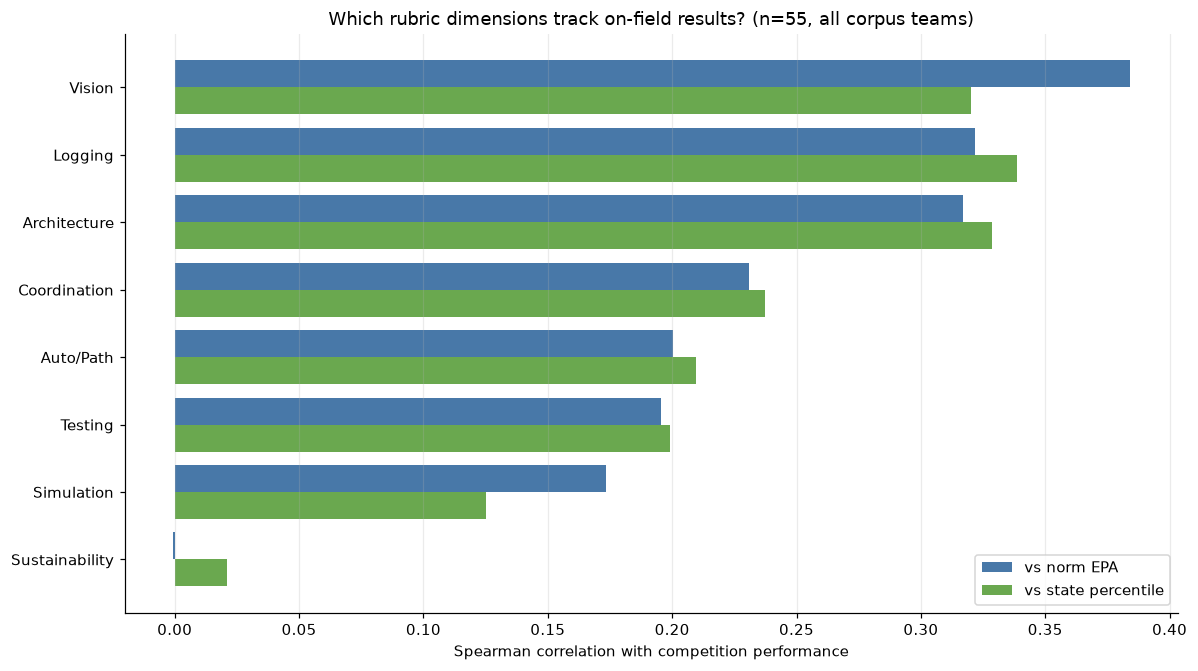

,normEPA,state
dim,,
Vision,0.38,0.32
Logging,0.32,0.34
Architecture,0.32,0.33
Coordination,0.23,0.24
Auto/Path,0.20,0.21
Testing,0.20,0.20
Simulation,0.17,0.13
Sustainability,-0.00,0.02


In [3]:
DIM_NAME = {"D1":"Architecture","D2":"Coordination","D3":"Simulation","D4":"Testing",
            "D5":"Logging","D6":"Auto/Path","D7":"Vision","D8":"Sustainability"}
rows = [{"dim":DIM_NAME[d], "normEPA":spearman(ds[d], ds.norm_epa),
         "state":spearman(ds[d], ds.state_pctile)} for d in DIMS]
cor = pd.DataFrame(rows).sort_values("normEPA")   # ascending -> barh draws strongest on top
y = np.arange(len(cor)); h = 0.4
fig, ax = plt.subplots(figsize=(11, 6.2))
ax.barh(y+h/2, cor.normEPA, h, color=NAT, label="vs norm EPA")
ax.barh(y-h/2, cor.state,   h, color=GREEN, label="vs state percentile")
ax.set_yticks(y); ax.set_yticklabels(cor.dim)
ax.set_xlabel("Spearman correlation with competition performance")
ax.set_title(f"Which rubric dimensions track on-field results? (n={len(ds)}, all corpus teams)")
ax.legend(loc="lower right"); ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()
display(cor.iloc[::-1].round(2).set_index("dim"))

**Why this ranking differs from the original (24 hand-scored CA teams).** Three reasons, all
expected: (1) these are **automated** candidate scores — noisier than hand scores, which compresses
every correlation (max ≈ 0.38 here vs ≈ 0.60 originally). (2) **Sustainability (D8)** is measured
here from **git history** (contributor count, multi-year continuity, a team library, CI) rather than
the original's *artifact hygiene* (README/CI/lib presence) — and the history-based version **does not
track EPA**, where the hand-scored one did (a likely program-age confound: older, better-resourced
programs had both better hygiene *and* better results). (3) **normalized EPA** across many states is
a looser signal than within-California **state percentile**. What survives both methods: **Vision**
and **Architecture** track results; **Simulation** and **Testing** barely do (engineering-quality
investments, not point-scorers).

## Figure 2 — code sophistication vs. results, with San Diego highlighted

Each team's rubric total vs. its normalized EPA. **San Diego teams in orange, the rest in blue** —
so you can see where San Diego sits in the whole distribution. The recompute of `fig_scatter.png`.

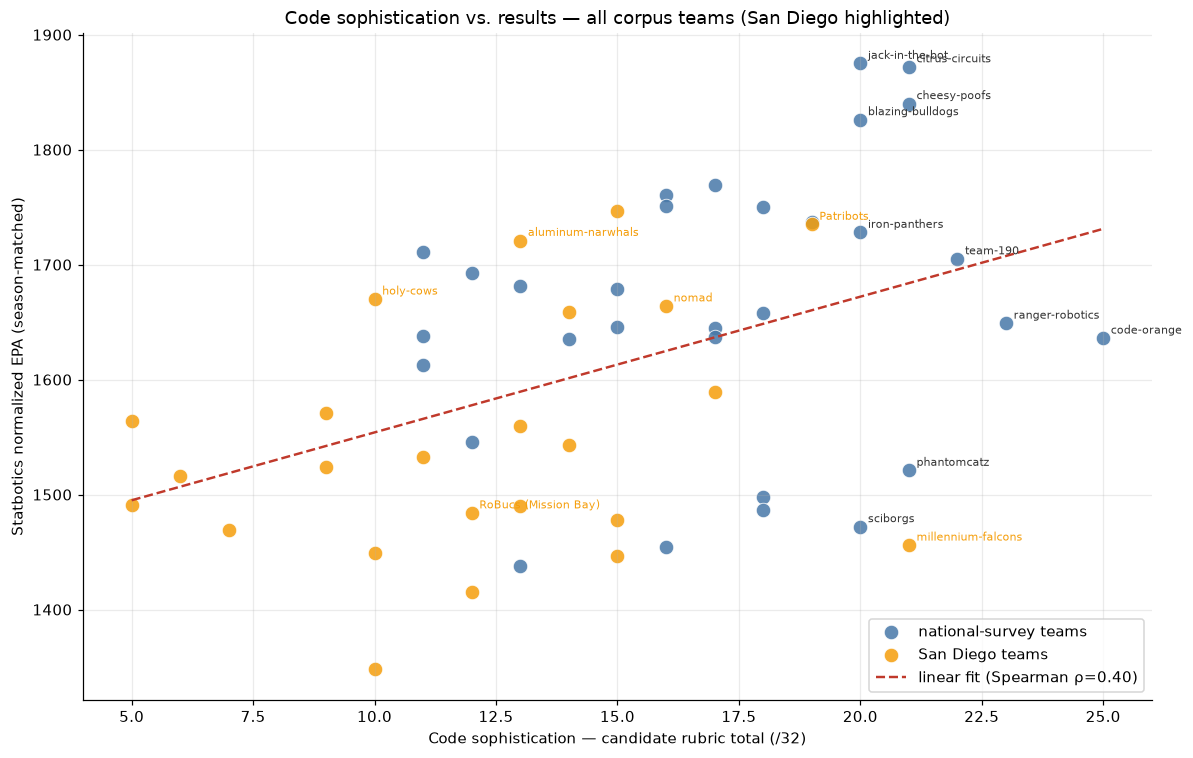

Spearman ρ (sophistication vs normEPA): 0.40  |  San Diego median total 12 vs national 17


In [4]:
rho = spearman(ds.total, ds.norm_epa)
fig, ax = plt.subplots(figsize=(11, 7))
for flag, color, lab in [(False, NAT, "national-survey teams"), (True, SD, "San Diego teams")]:
    s = ds[ds.is_sandiego == flag]
    ax.scatter(s.total, s.norm_epa, c=color, s=90, alpha=.85, edgecolor="white", linewidth=.6, label=lab)
# OLS trend line (labelled with Spearman rho, matching the original)
m, b = np.polyfit(ds.total, ds.norm_epa, 1)
xs = np.array([ds.total.min(), ds.total.max()])
ax.plot(xs, m*xs+b, "--", color=FIT, lw=1.6, label=f"linear fit (Spearman ρ={rho:.2f})")
# label the highest-sophistication teams, the SD↔national overlaps, and named San Diego teams
lab_teams = (set(ds.sort_values("total").tail(11).team)
             | {3128, 1538, 6995}              # SD teams also in the national survey
             | {4738, 4160})                    # Patribots, Robucs (named)
LABEL = {4160: "RoBucs (Mission Bay)", 4738: "Patribots"}   # clearer display names
for _, r in ds[ds.team.isin(lab_teams)].iterrows():
    ax.annotate(LABEL.get(r.team, r["name"]), (r.total, r.norm_epa), fontsize=7.5,
                xytext=(5, 3), textcoords="offset points",
                color=(SD if r.is_sandiego else "#333"))
ax.set_xlabel("Code sophistication — candidate rubric total (/32)")
ax.set_ylabel("Statbotics normalized EPA (season-matched)")
ax.set_title("Code sophistication vs. results — all corpus teams (San Diego highlighted)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()
print(f"Spearman ρ (sophistication vs normEPA): {rho:.2f}  |  San Diego median total "
      f"{ds[ds.is_sandiego].total.median():.0f} vs national {ds[~ds.is_sandiego].total.median():.0f}")

## Does San Diego have the same drivers as everyone else?

Per-dimension correlation with EPA computed **separately** for San Diego vs. the national-survey
teams — do the same rubric dimensions predict results locally as nationally?

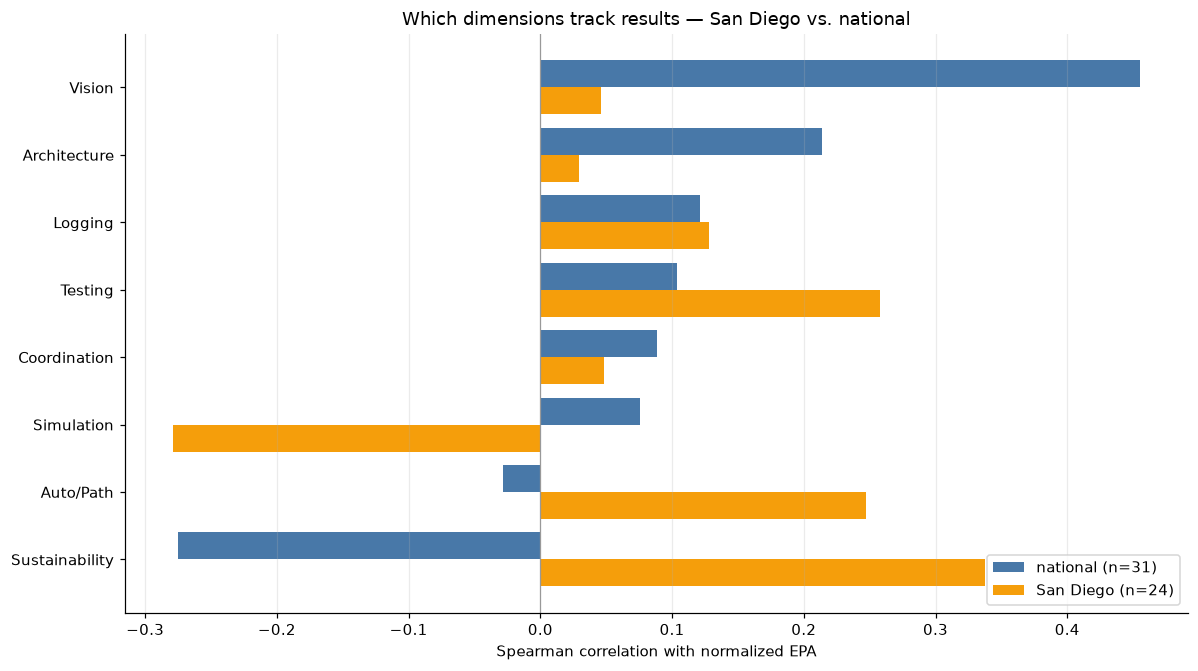

In [5]:
def by_group(mask):
    g = ds[mask]
    return {DIM_NAME[d]: spearman(g[d], g.norm_epa) for d in DIMS}
sd_c, nat_c = by_group(ds.is_sandiego), by_group(~ds.is_sandiego)
order = sorted(DIM_NAME.values(), key=lambda d: nat_c[d])
y = np.arange(len(order)); h = 0.4
fig, ax = plt.subplots(figsize=(11, 6.2))
ax.barh(y+h/2, [nat_c[d] for d in order], h, color=NAT, label=f"national (n={(~ds.is_sandiego).sum()})")
ax.barh(y-h/2, [sd_c[d] for d in order], h, color=SD,  label=f"San Diego (n={ds.is_sandiego.sum()})")
ax.set_yticks(y); ax.set_yticklabels(order); ax.axvline(0, color="#999", lw=.8)
ax.set_xlabel("Spearman correlation with normalized EPA")
ax.set_title("Which dimensions track results — San Diego vs. national"); ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0); plt.tight_layout(); plt.show()

---
*Generated by `scripts/build_correlation_notebook.py` from `data/code-index.duckdb` +
`data/master-dataset.json`. Rubric levels are the **automated** candidate pass (confirm by reading
before citing a team's score); EPA is season-matched Statbotics. Dataset: `data/rubric-epa-dataset.csv`.*